In [1]:
import warnings

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io.fits.verify import VerifyWarning

import sunpy.map
from sunpy.data.sample import AIA_171_IMAGE

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=VerifyWarning)
    amap = sunpy.map.Map(AIA_171_IMAGE)
amap.coordinate_frame


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

AIA20110607_063302_0171_lowres.fits:   0%|          | 0.00/973k [00:00<?, ?B/s]

<Helioprojective Frame (obstime=2011-06-07T06:33:02.880, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-06-07T06:33:02.880, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406429, 0.04787238, 1.51846026e+11)>)>

In [5]:
amap.observer_coordinate,amap.date

(<SkyCoord (HeliographicStonyhurst: obstime=2011-06-07T06:33:02.880, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
     (-0.00406429, 0.04787238, 1.51846026e+11)>,
 <Time object: scale='utc' format='isot' value=2011-06-07T06:33:02.770>)

In [ ]:
from sunpy.coordinates import HeliographicCarrington, HeliographicStonyhurst, RotatedSunFrame
from datetime import datetime

In [16]:
datetime.strptime('2011-06-08 12:00:00', '%Y-%m-%d %H:%M:%S')

datetime.datetime(2011, 6, 8, 12, 0)

In [62]:
# region agent log
import json
import time

_AGENT_DEBUG_LOG_PATH = "/disk/plasma/xw2/PFSS/.cursor/debug-03cf96.log"

def _agent_log(hypothesisId: str, message: str, data: dict):
    payload = {
        "sessionId": "03cf96",
        "runId": "pre-fix",
        "hypothesisId": hypothesisId,
        "location": "test_code/sunpy_coord.ipynb:cell_4",
        "message": message,
        "data": data,
        "timestamp": int(time.time() * 1000),
    }
    with open(_AGENT_DEBUG_LOG_PATH, "a", encoding="utf-8") as file:
        file.write(json.dumps(payload, ensure_ascii=False) + "\n")
# endregion agent log

from astropy.time import Time

referenceTime = Time("2011-06-08 10:00:00")
rotationDurationHours = (amap.date - referenceTime).to(u.hour)

solo_observer = SkyCoord(0.*u.deg, -20.23638174*u.deg, 1.48279473e+11*u.m, frame=HeliographicStonyhurst, obstime='2011-06-06T00:00:00.000')
coord = SkyCoord(0 * u.deg, 10 * u.deg,1*u.solRad, frame=HeliographicStonyhurst, obstime=amap.date,
                 observer=solo_observer) #
coord_rotated = SkyCoord(RotatedSunFrame(base=coord, duration=rotationDurationHours))
# coord

In [44]:
coord

<SkyCoord (HeliographicCarrington: obstime=2011-06-07T06:33:02.770, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'mars'>): (lon, lat, radius) in (deg, deg, solRad)
    (0., 10., 1.)>

In [34]:
coord_rotated

<SkyCoord (RotatedSunHeliographicCarrington: base=<HeliographicCarrington Frame (obstime=2011-06-07T06:33:02.770, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-06-07T06:33:02.880, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00406429, 0.04787238, 1.51846026e+11)>)>, duration=-1.2270512731481482 d, rotation_model=howard): (lon, lat, radius) in (deg, deg, solRad)
    (100., 10., 1.)>

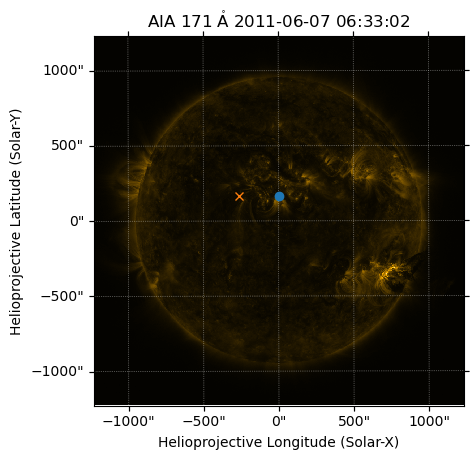

In [63]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = plt.subplot(projection=amap)
amap.plot()
ax.plot_coord(coord, 'o')
ax.plot_coord(coord_rotated, 'x')

observer 并不改变 locations of rotated points. 